In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

# 1. Load Dataset

In [2]:
file_path = "../datasets/phase_1/paysim-dataset.parquet"
df_clean = pd.read_parquet(file_path)
df_clean.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,-6.292167,-0.738877,0.214329,-0.857456,0,-2.510411,0.061098,1,0,0,0,0,1,0
1,-6.292167,-1.344428,0.034742,-0.857456,0,-2.510411,-0.094642,1,0,0,0,0,1,0
2,-6.292167,-2.191764,-0.376195,-0.857456,1,-2.510411,-0.312566,0,1,0,0,0,0,1
3,-6.292167,-2.191764,-0.376195,-0.133384,1,-2.510411,0.133690,0,1,0,1,0,0,0
4,-6.292167,-0.676824,0.092640,-0.857456,0,-2.510411,0.077058,1,0,0,0,0,1,0


In [3]:
X_clean = df_clean.drop(columns=['isFraud'], errors='ignore')

# 2. Dimentional Reduction

PCA is applied to reduce the feature dimensions to two principal components, enabling efficient clustering and visualization while retaining most of the data variability

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_clean)

print(X_reduced.shape)

(6362604, 2)


Initially, PCA was configured to retain 95% of the total variance (n_components=0.95). However, the resulting number of principal components remained relatively high, providing limited dimensionality reduction and reducing the computational efficiency of the subsequent clustering algorithms.

Therefore, the number of principal components was fixed to two (n_components=2). The resulting two principal components preserve approximately 69.76% of the total variance, indicating that most of the information in the original dataset is retained while substantially reducing the feature space. This configuration also enables efficient clustering and two-dimensional visualization

In [5]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.37189105 0.3256889 ]
0.69758


The first principal component explains approximately 37.19% of the total variance, while the second principal component explains approximately 32.57%. Together, both principal components retain approximately 69.76% of the total variance, demonstrating that the two-dimensional representation preserves most of the information contained in the original dataset

# 3. Elbow Method

This section determines the optimal number of clusters (K) for K-Means clustering.

Two validation techniques are used:
- Elbow Method
- Approximate Silhouette Score

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [7]:
X_clean = X_clean.astype(np.float64)
def approximate_silhoutte_score(X, labels, centroids):
    distances = cdist(X, centroids, metric='euclidean')
    # a(i): distance to centroid of the cluster (intra)
    a = distances[np.arange(len(labels)), labels]

    # b(i): distance centroid to nearest centroid, except the self cluster
    temp = distances.copy()
    temp[np.arange(len(labels)), labels] = np.inf
    b = temp.min(axis=1)

    # Approximate silhoutte
    s = (b-a)/np.maximum(a, b)
    return np.mean(s)

An approximate silhouette score is used to efficiently evaluate cluster quality on the 6.3 million-record dataset without the high computational cost of the standard silhouette score.

In [8]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)
wcss = []
silhouette_scores = []
db_scores = []
ch_scores = []

for i in range(2, 8):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_clean)
    # WCSS
    wcss.append(kmeans.inertia_)
    # Silhouette
    sil_score = approximate_silhoutte_score(
        X_clean,
        labels,
        kmeans.cluster_centers_
    )
    silhouette_scores.append(sil_score)
    # Davies-Bouldin
    db = davies_bouldin_score(X_clean, labels)
    db_scores.append(db)
    # Calinski-Harabasz
    ch = calinski_harabasz_score(X_clean, labels)
    ch_scores.append(ch)
    print(
        f"K={i}"
        f" | WCSS={kmeans.inertia_:.2f}"
        f" | Silhouette={sil_score:.4f}"
        f" | DBI={db:.4f}"
        f" | CH={ch:.2f}"
    )

K=2 | WCSS=22804507.56 | Silhouette=0.4435 | DBI=1.3631 | CH=2862711.66
K=3 | WCSS=15681029.11 | Silhouette=0.4856 | DBI=1.0731 | CH=3526764.46
K=4 | WCSS=12954398.43 | Silhouette=0.5019 | DBI=0.9821 | CH=3292447.86
K=5 | WCSS=10339836.16 | Silhouette=0.5391 | DBI=0.9381 | CH=3495954.93
K=6 | WCSS=8706001.68 | Silhouette=0.5479 | DBI=1.0021 | CH=3560436.13
K=7 | WCSS=7777425.70 | Silhouette=0.5414 | DBI=1.0888 | CH=3447883.45


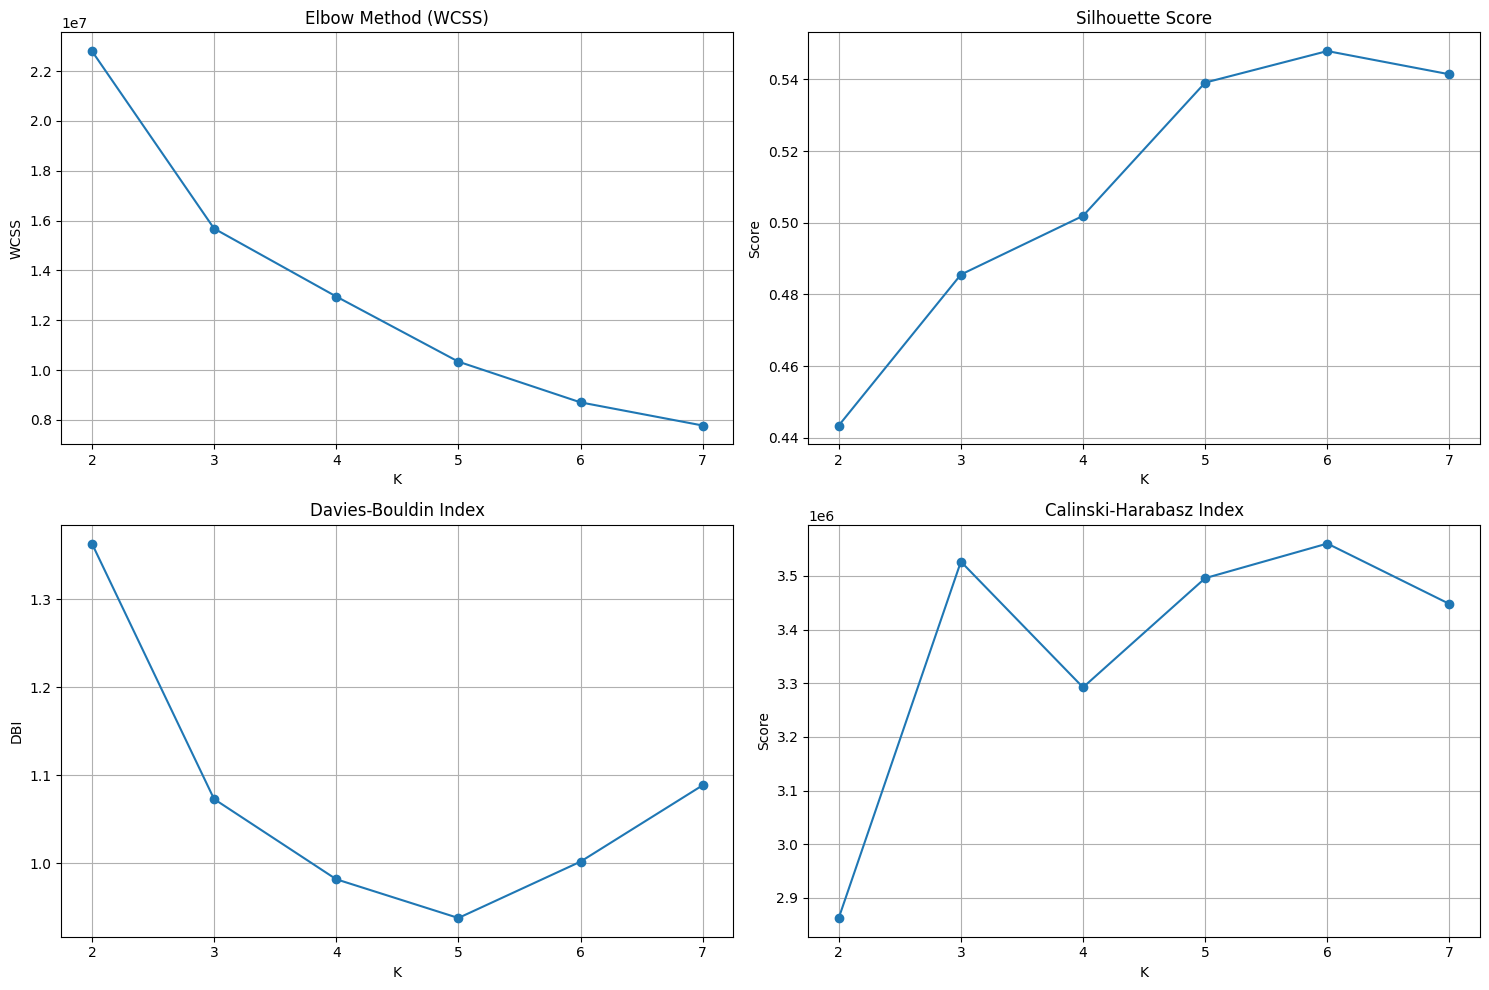

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# WCSS
axes[0,0].plot(range(2,8), wcss, marker="o")
axes[0,0].set_title("Elbow Method (WCSS)")
axes[0,0].set_xlabel("K")
axes[0,0].set_ylabel("WCSS")
axes[0,0].grid(True)

# Silhouette
axes[0,1].plot(range(2,8), silhouette_scores, marker="o")
axes[0,1].set_title("Silhouette Score")
axes[0,1].set_xlabel("K")
axes[0,1].set_ylabel("Score")
axes[0,1].grid(True)

# Davies-Bouldin
axes[1,0].plot(range(2,8), db_scores, marker="o")
axes[1,0].set_title("Davies-Bouldin Index")
axes[1,0].set_xlabel("K")
axes[1,0].set_ylabel("DBI")
axes[1,0].grid(True)

# Calinski-Harabasz
axes[1,1].plot(range(2,8), ch_scores, marker="o")
axes[1,1].set_title("Calinski-Harabasz Index")
axes[1,1].set_xlabel("K")
axes[1,1].set_ylabel("Score")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

The WCSS curve shows a clear bend around K = 3-4, after which additional clusters yield only marginal reductions in within-cluster variance. The Approximate Silhouette Score keeps improving up to K = 6 (peaking at 0.5479), while the Davies-Bouldin Index reaches its best (lowest) value at K = 5 (0.9381), indicating the most compact and well-separated clusters at that point; the Calinski-Harabasz Index also peaks around K = 6. Balancing these four indicators, K = 5 is selected for the subsequent K-Means clustering analysis.

# 4. KMeans Clustering

In [10]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_clean['cluster_kmeans'] = kmeans.fit_predict(X_clean)
# df_sample['cluster_kmeans'] = df_clean.loc[df_sample.index, 'cluster_kmeans']

K-Means clustering is applied using K = 5, the number of clusters selected by balancing the Elbow Method, Approximate Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index evaluated in the previous section.

# 5. HDBSCAN Outlier Detection

In [11]:
import hdbscan

# Stratified Sampling
sample_size = 300000

type_cols = [
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

# Recover transaction type
transaction_type = df_clean[type_cols].idxmax(axis=1)

fractions = transaction_type.value_counts(normalize=True)

sample_indices = []

for t, frac in fractions.items():
    n = int(sample_size * frac)

    idx = (
        transaction_type[transaction_type == t]
        .sample(n=n, random_state=42)
        .index
    )

    sample_indices.extend(idx)

sample_indices = np.array(sample_indices)

X_clean_sample = X_clean.loc[sample_indices]

# HDBSCAN
hdbscan_cpu = hdbscan.HDBSCAN(
    min_cluster_size=3000,
    min_samples=20,
    prediction_data=True,
    core_dist_n_jobs=-1,
    cluster_selection_method="eom"
)
hdbscan_cpu.fit(X_clean_sample)

# Approximate Predict
batch_size = 500000
all_labels = []

for i in range(0, len(X_clean), batch_size):
    X_batch = X_clean[i:i+batch_size]

    batch_labels, _ = hdbscan.approximate_predict(
        hdbscan_cpu,
        X_batch
    )

    all_labels.extend(batch_labels)

df_clean["cluster_hdbscan"] = all_labels

outlier_count = (df_clean["cluster_hdbscan"] == -1).sum()

print(f"Outlier count from HDBSCAN (label -1): {outlier_count:,}")

# Cleanup RAM
del (
    transaction_type,
    sample_indices,
    X_clean_sample,
    hdbscan_cpu,
    all_labels,
    X_batch,
    batch_labels,
)

gc.collect()

Outlier count from HDBSCAN (label -1): 197,928


0

The clustering process detected 197,928 transactions as outliers (label `-1`), representing approximately 3.1% of the dataset

Although the outlier proportion itself is modest, the direct HDBSCAN run still produced a large number of separate density clusters (18 in total) with highly uneven sizes, ranging from 75,320 to 1,020,735 transactions. This suggests that the financial transaction data contains many small, locally dense pockets rather than a small number of clearly separated global clusters

As a result, although HDBSCAN successfully identified several dense groups, the large number of fragmented clusters makes the direct HDBSCAN result difficult to use as a compact segmentation, motivating the hybrid approach explored in Section 7

After clustering, the number of transactions assigned to each cluster was calculated to evaluate the balance of the resulting clusters and determine whether meaningful groups were formed

In [12]:
cluster_counts = (
    df_clean["cluster_hdbscan"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

print(f"Cluster number : {df_clean['cluster_hdbscan'].nunique()-1}")
print(f"Largest cluster : {cluster_counts.max()}")
print(f"Smallest cluster : {cluster_counts[cluster_counts.index!=-1].min()}")

cluster_hdbscan
-1      197928
 0      326568
 1      116903
 2      868246
 3      656737
 4      224224
 5      282183
 6      251793
 7      152536
 8       75320
 9      102249
 10     170068
 11     853761
 12     100307
 13      84546
 14     135224
 15    1020735
 16     210766
 17     532510
Name: count, dtype: int64
Cluster number : 18
Largest cluster : 1020735
Smallest cluster : 75320


HDBSCAN identified 18 clusters in addition to the outlier group. However, the clustering result remained highly imbalanced

The largest cluster contained 1,020,735 transactions, while the smallest cluster contained 75,320 transactions. The outlier group itself contained 197,928 transactions (about 3.1% of the dataset) — comparatively small in size, but responsible for a disproportionate 4.13% fraud rate, containing 8,178 of the dataset's 8,197 fraud cases (about 99.8%)

These results indicate that while HDBSCAN's density-based clusters mostly capture large, structurally homogeneous groups of legitimate transactions, the resulting 18-cluster segmentation is too fragmented to be practically useful, and HDBSCAN alone was considered unsuitable as a general-purpose clustering method for this dataset

To obtain a more compact and computationally efficient clustering, a hybrid approach combining BIRCH and HDBSCAN was investigated. BIRCH was first used to summarize the dataset into representative subclusters, after which HDBSCAN was applied to the subcluster centers instead of directly to millions of individual transactions

# 6. Hierarchical Cluster

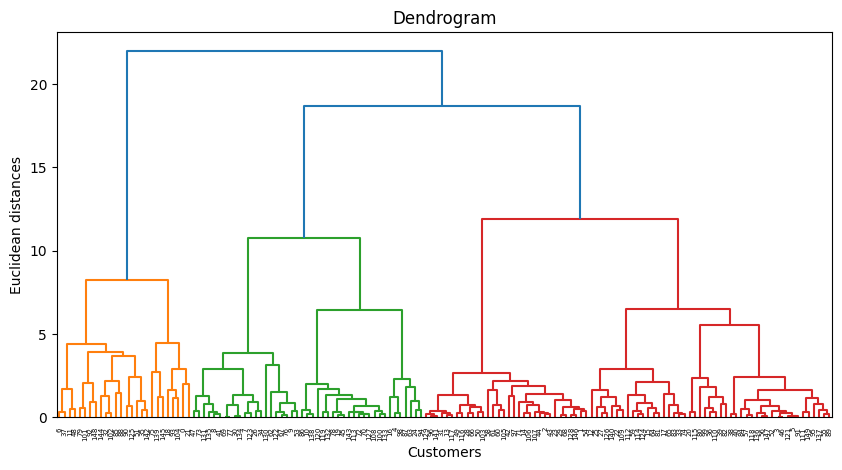

In [13]:
import scipy.cluster.hierarchy as sch

df_dendro = df_clean.sample(150, random_state=42)
plt.figure(figsize=(10, 5))
plt.title('Dendrogram')
dendrogram = sch.dendrogram(sch.linkage(df_dendro.drop(columns=['cluster_kmeans', 'cluster_hdbscan', 'isFraud'], errors='ignore'), method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

BIRCH is used as the hierarchical clustering algorithm because it efficiently builds a CF Tree, making it suitable for clustering the 6.3 million-record PaySim dataset.

In [14]:
step = max(1, len(X_clean) // 100000)

X_birch_tune = X_clean.iloc[::step].copy()
X_birch_tune = X_birch_tune.astype(np.float32)

To determine the appropriate BIRCH threshold, several threshold values were evaluated using a sample of the dataset. The number of generated subclusters and execution time were recorded for each configuration

In [15]:
from sklearn.cluster import Birch
import pandas as pd
import time

thresholds = [0.3, 0.4, 0.5, 0.6]

results = []

for t in thresholds:
    print(f"Testing threshold = {t}")
    start = time.time()

    birch = Birch(
        threshold=t,
        branching_factor=50,
        n_clusters=None
    )
    birch.fit(X_birch_tune)
    elapsed = time.time() - start
    n_subclusters = len(birch.subcluster_centers_)

    results.append({
        "Threshold": t,
        "Subclusters": n_subclusters,
        "Time (sec)": round(elapsed, 2)
    })

    results_df = pd.DataFrame(results)

display(results_df)

Testing threshold = 0.3
Testing threshold = 0.4
Testing threshold = 0.5
Testing threshold = 0.6


,Threshold,Subclusters,Time (sec)
0,0.3,1330,3.84
1,0.4,725,3.43
2,0.5,469,2.67
3,0.6,274,2.51


As the threshold increases, the number of generated subclusters decreases, resulting in faster execution. A threshold value of 0.3 was selected because it preserves the most structural detail (the highest subcluster count, 1,330, on the tuning sample) while still being fast enough (under 4 seconds) for practical use, offering the best balance between granularity and computational efficiency

In [16]:
from sklearn.cluster import Birch

birch = Birch(
    threshold=0.3,
    branching_factor=50,
    n_clusters=None
)

birch.fit(X_clean)
print("Subclusters:", len(birch.subcluster_centers_))

Subclusters: 4138


BIRCH was trained on the full dataset using the selected threshold (0.3) to generate representative subclusters for subsequent clustering

The selected threshold produced 4,138 subclusters, which were used as compact representatives of the original dataset

In [17]:
from sklearn.cluster import MiniBatchKMeans

subcluster_centers = birch.subcluster_centers_

mbk = MiniBatchKMeans(
    n_clusters=5,
    random_state=42,
    batch_size=512
)

mbk.fit(subcluster_centers)
print(mbk.cluster_centers_)

subcluster_to_cluster = mbk.labels_
print(subcluster_to_cluster.shape)

[[-4.8034824  -1.15297167 -0.06133626 -0.30368992 -1.91928816 -0.1100369
   0.15335031  0.27859961  0.08234989  0.25443787  0.2495069   0.15335031
   0.26035503]
 [ 0.11295061 -1.53977664 -0.12047439 -0.26206624 -1.87294969 -0.38160615
   0.13083024  0.30657516  0.13412038  0.34410789  0.18502154  0.13083024
   0.20591995]
 [-3.79917291  0.16262314 -0.17814098 -0.22743684  0.01978979 -0.06737456
   0.01398779  0.64649394  0.16226714  0.3636774   0.02569027  0.01398779
   0.43437739]
 [ 0.05624199  0.10236479 -0.11137939 -0.20876791 -0.21643424 -0.17169848
   0.04388122  0.73492204  0.12503702  0.42935738  0.03898363  0.04388122
   0.36274076]
 [-2.90963521 -1.11042375 -0.14096917 -0.22748811 -1.48878792 -0.24832206
   0.07993094  0.43634312  0.14412219  0.45769746  0.16207628  0.07993094
   0.15617314]]
(4138,)


MiniBatch K-Means was applied to the BIRCH subcluster centers to assign each subcluster into five global clusters

The resulting cluster centers represent the centroids of the five clusters, while each of the 4,138 subclusters receives a corresponding cluster label

In [18]:
subcluster_labels = birch.predict(X_clean)
final_labels = subcluster_to_cluster[subcluster_labels]
df_clean['cluster_birch'] = final_labels

Each original transaction was assigned to the cluster of its corresponding BIRCH subcluster

# 7. BIRCH + HDBSCAN

To improve anomaly detection, HDBSCAN was applied to the BIRCH subcluster centers instead of clustering the entire dataset directly. This significantly reduced computational cost while preserving the underlying cluster structure

In [19]:
subcluster_centers = birch.subcluster_centers_.astype(np.float32)

hdbscan_birch = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    cluster_selection_method="eom",
    prediction_data=True
)

cluster_labels = hdbscan_birch.fit_predict(subcluster_centers)

print(f"Number of clusters : {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Outlier subclusters : {(cluster_labels==-1).sum()}")

subcluster_labels = birch.predict(X_clean)
final_labels = cluster_labels[subcluster_labels]
df_clean["cluster_birch_hdbscan"] = final_labels
print(df_clean["cluster_birch_hdbscan"].value_counts().sort_index())

gc.collect()

Number of clusters : 15
Outlier subclusters : 840
cluster_birch_hdbscan
-1     1267687
 0     2151491
 1       41359
 2      223095
 3     1175388
 4       17954
 5        3217
 6       80046
 7       17411
 8       35504
 9      187070
 10      60043
 11      17599
 12     152924
 13     128091
 14     803725
Name: count, dtype: int64


20411

HDBSCAN identified 15 dense clusters from the 4,138 BIRCH subcluster centers, labeling 840 subclusters (about 20% of subclusters) as outliers. Mapped back to the original transactions, this corresponds to 1,267,687 transactions (about 19.9% of the dataset) in the outlier group — a larger proportion than the 3.1% found when applying HDBSCAN directly (Section 5). However, clustering only 4,138 subcluster centers is far more computationally efficient than running approximate prediction across 6.3 million transactions, and, as shown in the profiling step (Section 8), this approach still succeeds in isolating a small, high-fraud-rate cluster (cluster 4, 8.76% fraud) that is later used to flag high-risk transactions

In [20]:
subcluster_sizes = pd.Series(subcluster_labels).value_counts()

print(subcluster_sizes.describe())

pd.Series(cluster_labels).value_counts().sort_index()

count      4138.000000
mean       1537.603673
std        8062.715086
min           1.000000
25%           6.000000
50%          38.000000
75%         307.750000
max      162040.000000
Name: count, dtype: float64


-1     840
 0     324
 1     466
 2     236
 3     264
 4     123
 5      86
 6      38
 7      44
 8     274
 9     319
 10     56
 11     96
 12    372
 13    135
 14    465
Name: count, dtype: int64

The size distribution of BIRCH subclusters was analyzed to understand how the original transactions were partitioned before HDBSCAN clustering

Most subclusters contain only a few transactions, while a small number of subclusters represent a very large portion of the dataset. This indicates that the transaction distribution is highly imbalanced, which is expected for large-scale financial transaction data

# 8. Profiling Cluster

In [21]:
# cluster_profiles = df_clean.groupby('cluster_kmeans').mean()
# print("Cluster Profile (Mean):")
# print(cluster_profiles)

def cluster_summary(df, cluster_col, target_col="isFraud"):
    print(f"Cluster Summary: {cluster_col}")

    # Data freq each cluster
    cluster_size = (
        df[cluster_col]
        .value_counts()
        .sort_index()
        .rename("Total")
    )
    print("\nCluster Size")
    display(cluster_size)

    # Fraud statitics
    fraud_rate = (
        df.groupby(cluster_col)[target_col]
        .agg(
            Fraud_Rate="mean",
            Fraud_Count="sum",
            Total="count"
        )
    )

    fraud_rate['Fraud_Rate'] *= 100

    print("\nFraud Statistics")
    display(fraud_rate.round(2))

    # Numerical profile
    cluster_profile = (
        df.groupby(cluster_col)
        .mean(numeric_only=True)
        .round(2)
    )

    print("\nCluster Profile")
    display(cluster_profile)

    return cluster_profile, fraud_rate



This function summarizes the clustering results by reporting the number of records in each cluster, the fraud statistics, and the average values of numerical features. These summaries are used to compare cluster characteristics and support business interpretation of the transaction segments

In [22]:
# KMeans Profile
profile_kmeans, fraud_kmeans = cluster_summary(
    df_clean,
    "cluster_kmeans"
)

# HDBSCAN Profile
profile_hdbscan, fraud_hdbscan = cluster_summary(
    df_clean,
    "cluster_hdbscan"
)

# BIRCH Profile
profile_birch, fraud_birch = cluster_summary(
    df_clean,
    "cluster_birch"
)

# BIRCH + HDBSCAN Profile
profile_birch, fraud_birch = cluster_summary(
    df_clean,
    "cluster_birch_hdbscan"
)

Cluster Summary: cluster_kmeans

Cluster Size


cluster_kmeans
0    2080968
1    1208281
2     952318
3    1177735
4     943302
Name: Total, dtype: int64


Fraud Statistics


,Fraud_Rate,Fraud_Count,Total
cluster_kmeans,,,
0,0.00,82,2080968
1,0.61,7424,1208281
2,0.07,675,952318
3,0.00,16,1177735
4,0.00,0,943302



Cluster Profile


...

cluster_birch_hdbscan
-1     1267687
 0     2151491
 1       41359
 2      223095
 3     1175388
 4       17954
 5        3217
 6       80046
 7       17411
 8       35504
 9      187070
 10      60043
 11      17599
 12     152924
 13     128091
 14     803725
Name: Total, dtype: int64


Fraud Statistics


,Fraud_Rate,Fraud_Count,Total
cluster_birch_hdbscan,,,
-1,0.39,4989,1267687
0,0.00,0,2151491
1,0.00,0,41359
2,0.00,0,223095
3,0.00,0,1175388
4,8.76,1572,17954
5,2.21,71,3217
6,0.00,0,80046
7,0.00,0,17411



Cluster Profile


,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,cluster_kmeans,cluster_hdbscan,cluster_birch
cluster_birch_hdbscan,,,,,,,,,,,,,,,,,
-1,-0.28,0.25,-0.73,0.11,0.00,-0.06,-0.73,0.0,0.01,0.0,0.85,0.0,0.0,0.15,0.34,9.51,2.76
0,-0.38,-0.82,-0.26,-0.86,0.00,-1.48,0.04,1.0,0.15,0.0,0.00,0.0,1.0,0.00,2.43,2.48,1.98
1,-0.40,-1.21,-0.09,0.08,0.00,-2.00,-0.71,0.0,0.14,0.0,0.00,1.0,0.0,0.00,1.26,-1.00,1.53
2,-3.05,0.16,0.29,0.01,0.00,0.27,0.35,0.0,0.00,1.0,0.00,0.0,0.0,0.00,2.00,10.15,2.08
3,0.13,0.15,0.29,0.00,0.00,0.27,0.35,0.0,0.00,1.0,0.00,0.0,0.0,0.00,3.00,14.62,2.98
4,0.08,-0.04,0.22,-0.16,0.09,-2.51,-0.66,0.0,0.09,0.0,0.00,0.0,0.0,1.00,1.00,-1.00,1.06
5,-3.22,-0.01,0.24,-0.04,0.02,-2.51,-0.38,0.0,0.02,0.0,0.00,0.0,0.0,1.00,1.98,-1.00,2.98
6,0.20,0.40,-0.83,0.17,0.00,0.27,-0.65,0.0,0.00,0.0,0.00,0.0,0.0,1.00,0.01,5.00,3.00
7,-3.61,0.45,-0.83,0.16,0.00,0.30,-0.14,0.0,0.00,0.0,0.00,0.0,0.0,1.00,2.00,4.98,2.02


The cluster profiling results show that each clustering algorithm captures different characteristics of the transaction data.

K Means produced five clusters with relatively balanced distributions compared to the other methods, ranging from 943,302 to 2,080,968 transactions. The largest cluster (cluster 0) represented normal transactions with almost no fraud, while cluster 1 showed the highest fraud rate among the K Means clusters (0.61%, 7,424 fraud cases) — roughly 4-5 times the overall dataset fraud rate (~0.13%). Since the differences between clusters remained modest overall, K Means is more suitable for general transaction segmentation than for fraud isolation.

HDBSCAN identified 18 clusters together with a smaller noise group of 197,928 transactions (about 3.1% of the dataset). Nearly all fraud cases in the dataset — 8,178 of 8,197 (about 99.8%) — fell within this noise group, giving it a fraud rate of 4.13%, far higher than any of the 18 identified density clusters (all at or below 0.01% fraud). This shows that while HDBSCAN's density-based clusters mainly represent large, homogeneous groups of legitimate transactions, its noise label alone is a strong indicator of suspicious activity.

BIRCH generated five clusters by compressing the dataset into 4,138 representative subclusters. Most transactions were concentrated in a single dominant cluster (cluster 3, about 3.92 million transactions, 61.6% of the dataset), while the remaining clusters were considerably smaller. Fraud rates across all five BIRCH clusters stayed low, ranging from 0.01% to 0.26%, indicating that BIRCH's cluster assignments alone do not meaningfully separate fraudulent from legitimate transactions.

The combination of BIRCH and HDBSCAN identified 15 clusters plus a noise group of 1,267,687 transactions (19.9% of the dataset, 0.39% fraud rate). Most transactions were concentrated in a few larger clusters, particularly cluster 0 (2,151,491 transactions) and cluster 14 (803,725 transactions), both with near-zero fraud rates. Notably, cluster 4 — a comparatively small group of 17,954 transactions — showed a fraud rate of 8.76% (1,572 fraud cases), roughly 68 times the overall dataset fraud rate. This demonstrates that the combined approach is effective at concentrating suspicious transactions into a compact, high-risk cluster.

Overall, the results indicate that K Means is the most appropriate method for general transaction segmentation because it provides relatively balanced and interpretable clusters. In contrast, the BIRCH and HDBSCAN combination is the most suitable approach for anomaly detection, since it isolates a small, compact cluster (cluster 4) with a fraud concentration far above the dataset average — a result that is used in Section 10 to flag high-risk transactions for the next phase.

# 9. Cluster Visualization

In [23]:
# X_viz = X_clean.copy()
# viz_cols = ["amount", "oldbalanceOrg", "oldbalanceDest", "origError", "destError"]
# for col in viz_cols:
#     lower = X_viz[col].quantile(0.01)
#     upper = X_viz[col].quantile(0.99)
#     X_viz[col] = X_viz[col].clip(lower, upper)

# pca_vis = PCA(n_components=2, random_state=42)
# X_pca_viz = pca_vis.fit_transform(X_viz)

# X_viz = X_clean.copy()
# pca_vis = PCA(n_components=2, random_state=42)
# X_pca = pca_vis.fit_transform(X_viz)

The PCA visualization provides an initial overview of the clustering results in a two dimensional space. Although PCA successfully reduces the dimensionality of the dataset, the resulting projection forms several elongated and overlapping structures. This indicates that the first two principal components preserve the overall variance of the data but are unable to clearly reveal the local relationships between transactions

### 9.1. Scatter Plot

Explained Variance Ratio: [0.37189388 0.32568396]
Total Variance: 0.6975778455243788


C:\Users\fance\AppData\Local\Temp\ipykernel_18736\344074934.py:76: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\fance\.conda\envs\data-mining\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


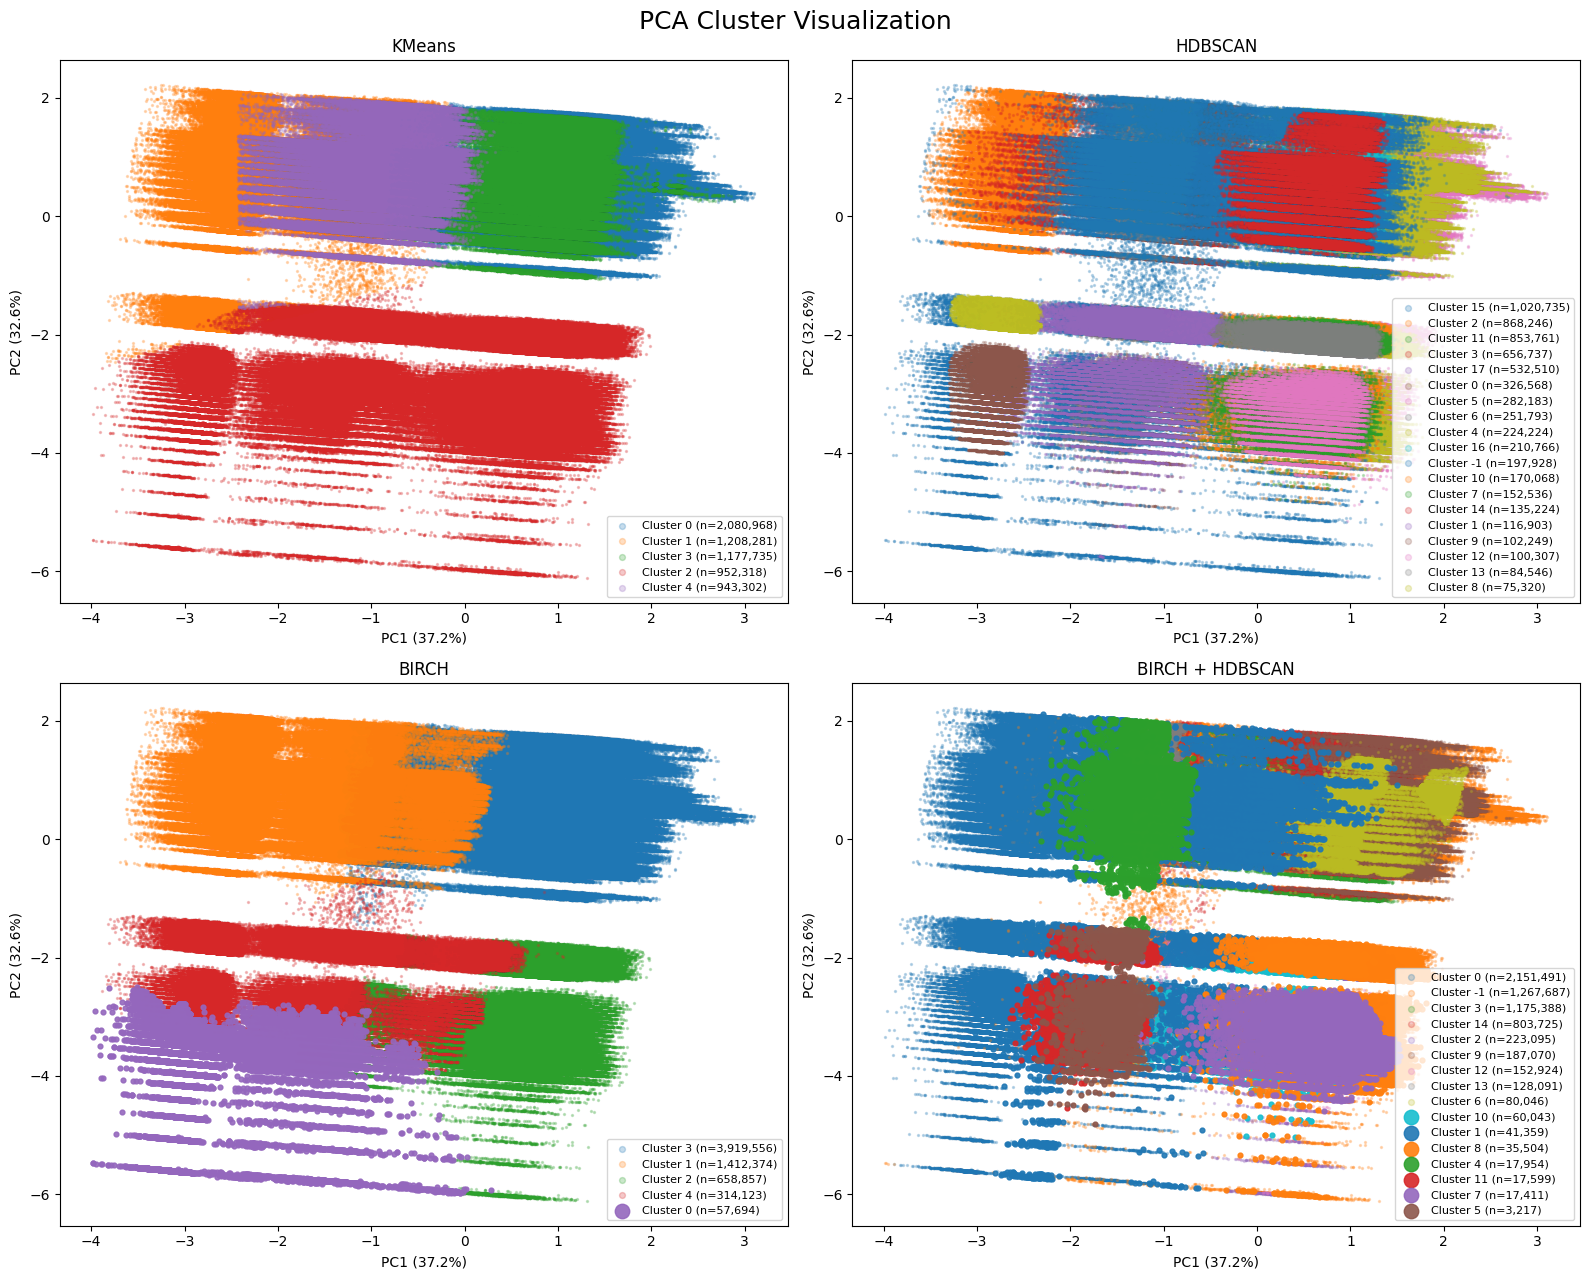

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================
# PCA pada data SAMPLE
# ==========================
X_viz = X_clean.copy()      # X_sample = hasil sampling yang sama dengan df_sampled

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_viz)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance:", pca.explained_variance_ratio_.sum())

# ==========================
# Plot
# ==========================
cluster_dict = {
    "KMeans": df_clean["cluster_kmeans"],
    "HDBSCAN": df_clean["cluster_hdbscan"],
    "BIRCH": df_clean["cluster_birch"],
    "BIRCH + HDBSCAN": df_clean["cluster_birch_hdbscan"],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

cmap = plt.get_cmap("tab10")

for ax, (title, labels) in zip(axes.ravel(), cluster_dict.items()):

    labels = labels.reset_index(drop=True)

    # gambar cluster besar dulu
    order = sorted(
        labels.unique(),
        key=lambda c: -(labels == c).sum()
    )

    for i, cid in enumerate(order):

        mask = labels == cid

        cluster_size = mask.sum()

        is_minor = cluster_size < 0.01 * len(labels)

        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=12 if is_minor else 2,
            alpha=0.9 if is_minor else 0.25,
            color=cmap(i % 10),
            label=f"Cluster {cid} (n={cluster_size:,})",
            zorder=2 if is_minor else 1
        )

    ax.set_title(title)
    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    )

    ax.legend(
        fontsize=8,
        markerscale=3,
        frameon=True
    )

plt.suptitle(
    "PCA Cluster Visualization",
    fontsize=18
)

plt.tight_layout()
plt.show()

K Means partitions the data into five regions based on distance, producing clear decision boundaries despite the continuous distribution of the data. In contrast, HDBSCAN's 18 clusters overlap heavily in this 2D PCA projection and are difficult to tell apart visually, even though only a small fraction of transactions (~3%) are actually labeled as noise. BIRCH shows one dominant cluster (about 62% of transactions) with several smaller clusters, while the BIRCH plus HDBSCAN approach shows a few larger clusters together with many small ones, both making the fine-grained cluster structure difficult to interpret using PCA alone

Since PCA is a linear dimensionality reduction technique, it may not preserve the nonlinear structure of complex transaction data. Therefore, UMAP and t SNE are applied in the following section to better visualize the local neighborhood relationships and evaluate whether the clusters become more distinguishable in a nonlinear embedding space

### 9.2 UMAP

In [25]:
!pip install umap-learn
!pip install plotly

c:\Users\fance\.conda\envs\data-mining\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fance\.conda\envs\data-mining\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


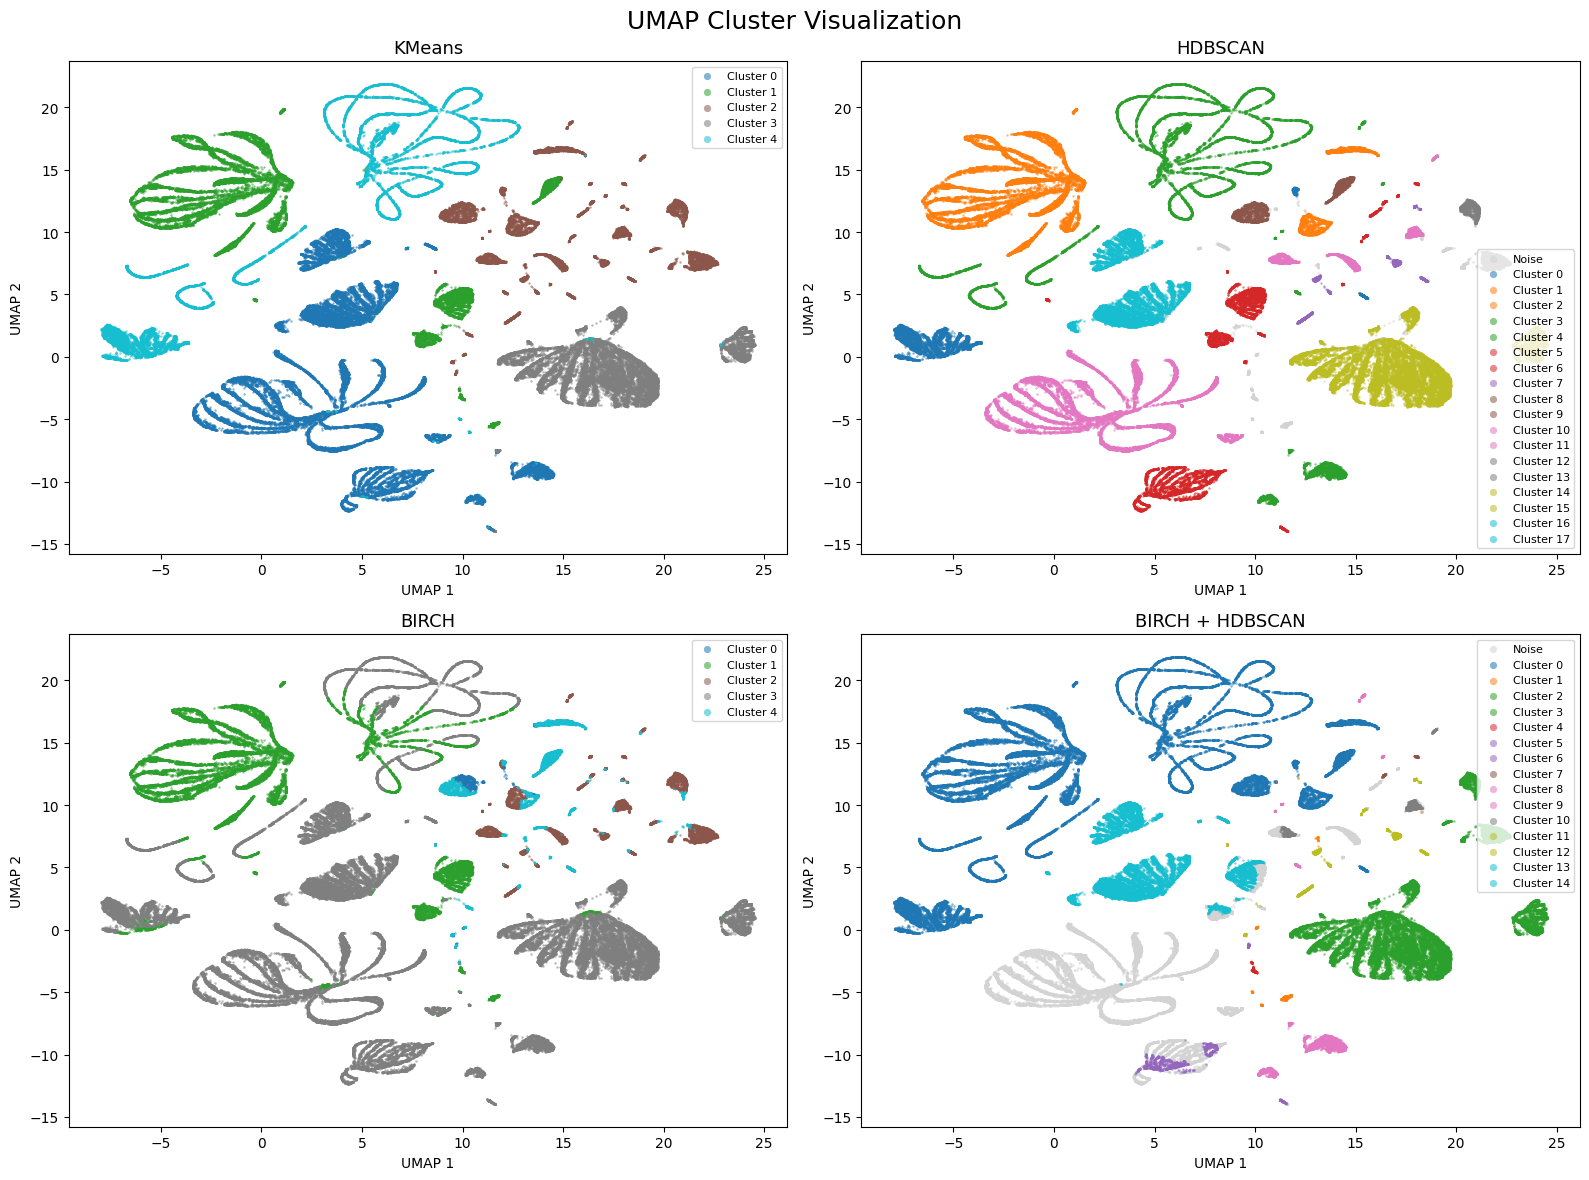

In [26]:
import umap

# ===========================
# Sampling
# ===========================
sample_size = 100000

rng = np.random.RandomState(42)
sample_idx = rng.choice(
    len(X_clean),
    sample_size,
    replace=False
)

X_sample = X_clean.iloc[sample_idx]

# ===========================
# UMAP
# ===========================
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample)

# ===========================
# Cluster labels
# ===========================
cluster_dict = {
    "KMeans": df_clean.loc[sample_idx, "cluster_kmeans"].values,
    "HDBSCAN": df_clean.loc[sample_idx, "cluster_hdbscan"].values,
    "BIRCH": df_clean.loc[sample_idx, "cluster_birch"].values,
    "BIRCH + HDBSCAN": df_clean.loc[sample_idx, "cluster_birch_hdbscan"].values,
}

# ===========================
# Plot
# ===========================
fig, axes = plt.subplots(2,2, figsize=(16,12))

for ax, (title, labels) in zip(axes.ravel(), cluster_dict.items()):
    unique_labels = np.sort(np.unique(labels))
    # Warna untuk setiap cluster
    colors = plt.cm.tab10(np.linspace(0,1,len(unique_labels)))
    color_map = {}

    for c, color in zip(unique_labels, colors):
        if c == -1:
            color_map[c] = "lightgray"      # noise HDBSCAN
        else:
            color_map[c] = color

    for cluster in unique_labels:
        idx = labels == cluster
        ax.scatter(
            X_umap[idx,0],
            X_umap[idx,1],
            s=3,
            alpha=0.55,
            color=color_map[cluster],
            linewidths=0,
            label=f"Cluster {cluster}" if cluster!=-1 else "Noise"
        )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    ax.legend(
        loc="best",
        fontsize=8,
        markerscale=3
    )

plt.suptitle("UMAP Cluster Visualization", fontsize=18)
plt.tight_layout()
plt.show()

The UMAP visualization preserves both local neighborhood information and part of the global data structure, resulting in a more continuous and organized representation of the dataset. Compared with t SNE, the manifold appears more connected and the relationships between neighboring regions are better preserved

The clustering patterns remain broadly consistent with the previous analysis. KMeans divides the embedding into five regions with relatively clear boundaries, demonstrating balanced cluster partitioning. HDBSCAN detects several dense regions together with a modest number of noise points (in line with the ~3% noise rate observed on the full dataset), showing its ability to identify clusters of varying density. Meanwhile, BIRCH still shows one cluster covering roughly 62% of transactions alongside several smaller ones, while BIRCH plus HDBSCAN shows a few larger clusters together with many small ones — both indicating that transaction density is highly uneven across the feature space. Overall, UMAP provides a more interpretable global structure while confirming the clustering characteristics observed in the quantitative evaluation

### 9.3 t-SNE

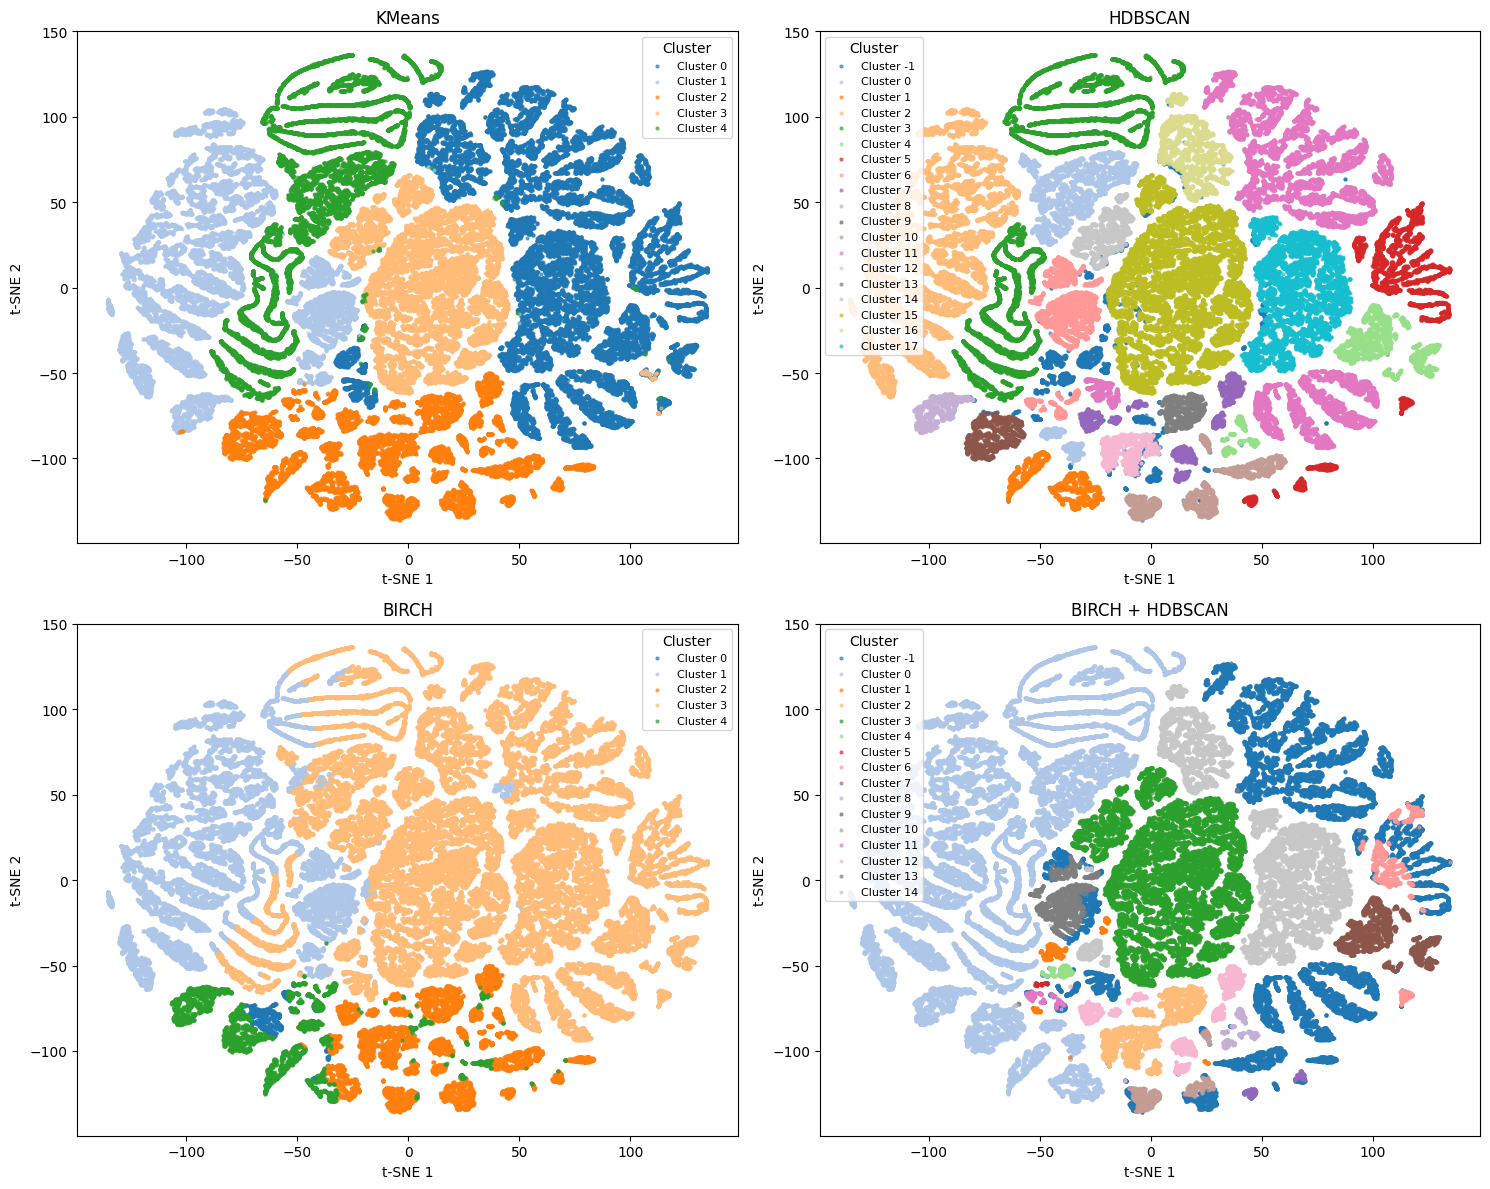

In [29]:
from sklearn.manifold import TSNE

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

# Plot
cluster_dict = {
    "KMeans": df_clean.loc[sample_idx, "cluster_kmeans"],
    "HDBSCAN": df_clean.loc[sample_idx, "cluster_hdbscan"],
    "BIRCH": df_clean.loc[sample_idx, "cluster_birch"],
    "BIRCH + HDBSCAN": df_clean.loc[sample_idx, "cluster_birch_hdbscan"],
}

fig, axes = plt.subplots(2,2, figsize=(15,12))

for ax, (title, labels) in zip(axes.ravel(), cluster_dict.items()):

    labels = np.array(labels)
    unique_labels = np.sort(np.unique(labels))

    cmap = plt.get_cmap("tab20")

    for i, cid in enumerate(unique_labels):
        mask = labels == cid

        ax.scatter(
            X_tsne[mask,0],
            X_tsne[mask,1],
            s=4,
            alpha=0.6,
            color=cmap(i),
            label=f"Cluster {cid}"
        )

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(title="Cluster", fontsize=8)

plt.tight_layout()
plt.show()

The t SNE visualization reveals the local neighborhood structure of the dataset by placing similar observations close to one another. Compared with the PCA visualization, the data forms several compact regions with clearer local separation, making it easier to observe the clustering behavior of each algorithm

The KMeans result partitions the manifold into five relatively continuous regions, indicating that centroid based clustering successfully separates the data into several distinct groups. HDBSCAN identifies multiple dense local clusters while assigning a modest share of observations (~3%) to the noise class, reflecting its density based clustering strategy. In contrast, BIRCH is dominated by one large cluster (roughly 62% of transactions) with a few smaller ones, while BIRCH plus HDBSCAN shows a few larger clusters together with several smaller ones, indicating that transaction density is uneven rather than perfectly separated. Overall, t SNE emphasizes local relationships and highlights how each clustering algorithm separates nearby observations

# 10. Export

In [28]:
folder_path = "../datasets/phase_2"
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

cluster_fraud_rate = df_clean.groupby('cluster_birch_hdbscan')['isFraud'].mean()
high_risk_cluster_id = cluster_fraud_rate.idxmax()

print(
    f"Highest fraud-rate cluster: {high_risk_cluster_id} "
    f"({cluster_fraud_rate.loc[high_risk_cluster_id] * 100:.2f}% fraud, "
    f"{(df_clean['cluster_birch_hdbscan'] == high_risk_cluster_id).sum():,} rows)"
)
df_clean['is_birch_hdbscan_outlier'] = (
    df_clean['cluster_birch_hdbscan'] == high_risk_cluster_id
).astype(int)

df_clean.to_parquet(os.path.join(folder_path, 'paysim-dataset-phase2.parquet'), index=False)

df_outliers = df_clean[df_clean['is_birch_hdbscan_outlier'] == 1].copy()
df_outliers.to_parquet(os.path.join(folder_path, 'paysim-outliers-phase4.parquet'), index=False)

cluster_profiles = df_clean.groupby('cluster_kmeans').mean(numeric_only=True)
cluster_profiles.to_csv(os.path.join(folder_path, 'cluster-summary-phase2.csv'))

del df_outliers, cluster_profiles
gc.collect()

Highest fraud-rate cluster: 4 (8.76% fraud, 17,954 rows)


27114